# Sales Lead Conversion & Segmentation Intelligence

**Author:** Nitin Prasad

**Notebook:** 01_Data_Cleaning_and_Prepration

---

## Project Overview

This project develops a machine learning-based sales intelligence system for a B2B SaaS company.

The system is designed to help the sales team:

1. Predict the probability that a lead will convert into a customer.
2. Identify distinct groups of leads based on their behavior and business characteristics.
3. Prioritize leads for sales follow-up using model predictions and business attributes.

The project combines **supervised learning** for lead conversion prediction and **unsupervised learning** for lead segmentation, with the final models deployed through a Streamlit application.

---

### Notebook Purpose

Clean and validate the raw lead dataset, perform exploratory data analysis, treat data-quality issues and outliers, and create features for machine learning.

**Input:** `Lead_Conversion_Data.csv`

**Output:** `cleaned_leads.csv`

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

---

## Machine Learning Preparation

The cleaned dataset will later be used for:

**Notebook 2:** 02_Lead_Conversion_Classification

**Notebook 3:** 03_Lead_Segmentation_Clustering

All features used for modeling must represent information that would be available **before the lead conversion outcome**, in order to avoid data leakage.

## 1. Import Libraries and Setup

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File and warning handling
from pathlib import Path
import warnings

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Visualization settings
sns.set_theme(style="whitegrid")

# Suppress unnecessary warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported and notebook setup completed successfully.")

Libraries imported and notebook setup completed successfully.


## 2. Load and Inspect Data

### 2.1 Load Raw Data

In [2]:
file_path = Path("../Dataset/Lead_Conversion_Data.csv")

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


### 2.2 Data Inspection

In [3]:
# Checking Dataset Dimensions
df.shape

(20000, 24)

In [4]:
# Preview the Raw records
display(df.head())

,Lead_ID,Lead_Date,Industry,State,Employee_Count,Lead_Source,Campaign_Type,Sales_Rep_Interactions,Previous_Interactions,Days_Since_Last_Interaction,Website_Visits,Pages_Viewed,Email_Opens,Email_Clicks,Content_Downloads,Demo_Attended,Estimated_Budget,Estimated_Deal_Value,Decision_Maker,Contact_Requests,Product_Page_Visits,Trial_Started,Converted,Conversion_Date
0,L003684,7/29/2026,Healthcare,Odisha,95,Google Ads,Enterprise Outreach,2.00,4.00,21.00,6.00,14.00,10.00,3.00,0.00,Yes,"81,000.00","60,000.00",No,0,NaN,No,0,NaN
1,L009526,11/21/2025,Retail,Kerala,101,Referral,Enterprise Outreach,2.00,3.00,36.00,15.00,22.00,13.00,1.00,1.00,No,"89,000.00","75,000.00",Yes,0,3.00,No,1,1/16/2026
2,L004328,4/17/2026,Manufacturing,Gujarat,109,LinkedIn,Content Marketing,1.00,2.00,50.00,21.00,59.00,8.00,2.00,4.00,No,"85,000.00","100,000.00",No,1,14.00,No,0,NaN
3,L004945,17-11-2024,IT Services,Madhya Pradesh,47,LinkedIn,Product Demo,5.00,14.00,NaN,18.00,36.00,NaN,4.00,2.00,Yes,"64,000.00","80,000.00",Yes,1,11.00,Yes,0,NaN
4,L004935,12/8/2025,Manufacturing,Gujarat,10,Google Ads,Webinar,1.00,4.00,24.00,4.00,5.00,7.00,1.00,0.00,No,"51,000.00","60,000.00",No,0,1.00,No,0,NaN


In [5]:
# Inspect Datatypes and Non-Null count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Lead_ID                      20000 non-null  object 
 1   Lead_Date                    20000 non-null  object 
 2   Industry                     19876 non-null  object 
 3   State                        19880 non-null  object 
 4   Employee_Count               20000 non-null  int64  
 5   Lead_Source                  19881 non-null  object 
 6   Campaign_Type                19877 non-null  object 
 7   Sales_Rep_Interactions       18916 non-null  float64
 8   Previous_Interactions        19506 non-null  float64
 9   Days_Since_Last_Interaction  19003 non-null  float64
 10  Website_Visits               18924 non-null  float64
 11  Pages_Viewed                 18727 non-null  float64
 12  Email_Opens                  18509 non-null  float64
 13  Email_Clicks    

## 3. Missing Value Audit

In [6]:
def count_per_null(data):
    nv = data.isnull().sum()
    nv = nv[nv>0]
    nv_df = pd.DataFrame({'Feature':nv.index,'Null_Count':nv.values,
                         'Null%':(nv.values/data.shape[0])*100})
    nv_df = nv_df.sort_values('Null%',ascending=False)  
    return nv_df

In [7]:
count_per_null(df)

,Feature,Null_Count,Null%
15,Conversion_Date,12002,60.01
12,Estimated_Budget,1564,7.82
9,Email_Opens,1491,7.46
10,Email_Clicks,1335,6.68
8,Pages_Viewed,1273,6.37
11,Content_Downloads,1178,5.89
4,Sales_Rep_Interactions,1084,5.42
7,Website_Visits,1076,5.38
14,Product_Page_Visits,1073,5.37
6,Days_Since_Last_Interaction,997,4.98


### 3.1 Validate Conversion Date Missingness

Check whether missing `Conversion_Date` values are consistent with the lead's conversion status.<br>
A conversion date should exist only for leads that converted.

In [8]:
pd.crosstab(
    df["Converted"],
    df["Conversion_Date"].isna(),
    margins=True)

Conversion_Date,False,True,All
Converted,,,
0,154,12002,12156
1,7844,0,7844
All,7998,12002,20000


### 3.2 Remove Unused Conversion Date

`Conversion_Date` is an outcome-related field and is not required for lead conversion prediction or lead segmentation.

To avoid potential data leakage and unnecessary complexity, the column will be removed from the modeling dataset after its business-rule validation.

In [9]:
df.drop(columns="Conversion_Date", inplace=True)

print("Conversion_Date column removed.")

Conversion_Date column removed.


In [10]:
count_per_null(df)

,Feature,Null_Count,Null%
12,Estimated_Budget,1564,7.82
9,Email_Opens,1491,7.46
10,Email_Clicks,1335,6.68
8,Pages_Viewed,1273,6.37
11,Content_Downloads,1178,5.89
4,Sales_Rep_Interactions,1084,5.42
7,Website_Visits,1076,5.38
14,Product_Page_Visits,1073,5.37
6,Days_Since_Last_Interaction,997,4.98
13,Estimated_Deal_Value,977,4.88


## 4. Duplicate Record Audit

In [11]:
duplicate_count = df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_count}")

Exact duplicate rows: 366


In [12]:
duplicate_rows = df[df.duplicated(keep=False)]

display(duplicate_rows.head(10))

,Lead_ID,Lead_Date,Industry,State,Employee_Count,Lead_Source,Campaign_Type,Sales_Rep_Interactions,Previous_Interactions,Days_Since_Last_Interaction,Website_Visits,Pages_Viewed,Email_Opens,Email_Clicks,Content_Downloads,Demo_Attended,Estimated_Budget,Estimated_Deal_Value,Decision_Maker,Contact_Requests,Product_Page_Visits,Trial_Started,Converted
25,L008759,5/3/2025,IT Services,Madhya Pradesh,110,Email Campaign,Free trial,3.00,10.00,46.00,10.00,29.00,7.00,NaN,3.00,No,"91,000.00","80,000.00",No,0,5.00,No,0
26,L009063,11/14/2025,Retail,Telangana,18,Referral,Content Marketing,6.00,9.00,35.00,34.00,81.00,9.00,1.00,9.00,Yes,"49,000.00","65,000.00",Yes,1,NaN,No,1
87,L016126,1/9/2024,Manufacturing,Haryana,11,LinkedIn,Webinar,6.00,8.00,NaN,31.00,71.00,9.00,11.00,5.00,Yes,"53,000.00","55,000.00",No,0,14.00,Yes,1
99,L008545,7/25/2025,Healthcare,Punjab,46,Email Campaign,NaN,4.00,6.00,2.00,19.00,30.00,8.00,2.00,3.00,No,"66,000.00","60,000.00",No,0,6.00,No,0
104,L000971,4/9/2025,Financial Services,Uttar Pradesh,5,Website,Webinar,1.00,3.00,39.00,NaN,0.00,6.00,NaN,2.00,Yes,"49,000.00","60,000.00",No,0,0.00,No,0
138,L001598,20-Oct-24,IT Services,Madhya Pradesh,31,Website,Webinar,2.00,4.00,33.00,21.00,55.00,6.00,1.00,4.00,No,"59,000.00","90,000.00",No,1,7.00,No,0
186,L018536,2/19/2024,Logistics,Madhya Pradesh,11,Referral,Product Demo,NaN,3.00,37.00,24.00,33.00,11.00,3.00,3.00,No,"49,000.00","75,000.00",No,1,4.00,No,1
195,L002559,2/1/2025,Manufacturing,Karnataka,56,Website,Product Demo,1.00,5.00,39.00,4.00,9.00,12.00,3.00,0.00,No,"70,000.00","65,000.00",No,0,1.00,No,0
223,L017028,11/7/2025,Manufacturing,Maharashtra,9,Email Campaign,Content Marketing,NaN,0.00,40.00,22.00,56.00,NaN,1.00,4.00,No,"51,000.00","45,000.00",Yes,0,10.00,No,0
274,L011286,3/8/2025,Professional Services,West Bengal,93,webinar,Content Marketing,3.00,3.00,46.00,9.00,31.00,7.00,2.00,NaN,No,"88,000.00","105,000.00",No,1,3.00,No,0


### 4.1 Remove Exact Duplicate Records

The raw dataset contains exact duplicate rows. Since these records contain identical information, they will be removed to prevent duplicate observations from influencing EDA and model training.

In [13]:
before = len(df)

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

after = len(df)

print(f"Rows before removing duplicates: {before:,}")
print(f"Rows after removing duplicates: {after:,}")
print(f"Duplicate rows removed: {before - after:,}")

Rows before removing duplicates: 20,000
Rows after removing duplicates: 19,634
Duplicate rows removed: 366


In [14]:
df.duplicated().sum()

np.int64(0)

### 4.2 Validate Lead ID Uniqueness

Check whether each `Lead_ID` appears only once.

A lead identifier should uniquely represent a single lead. Multiple records with the same `Lead_ID` may indicate duplicate or near-duplicate records.

In [15]:
lead_id_counts = df["Lead_ID"].value_counts()

duplicate_leads = lead_id_counts[lead_id_counts > 1]

print(f"Lead IDs appearing more than once: {len(duplicate_leads)}")

Lead IDs appearing more than once: 344


In [16]:
display(
    df[df["Lead_ID"].isin(duplicate_leads.index)]
    .sort_values("Lead_ID")
    .head(10))

,Lead_ID,Lead_Date,Industry,State,Employee_Count,Lead_Source,Campaign_Type,Sales_Rep_Interactions,Previous_Interactions,Days_Since_Last_Interaction,Website_Visits,Pages_Viewed,Email_Opens,Email_Clicks,Content_Downloads,Demo_Attended,Estimated_Budget,Estimated_Deal_Value,Decision_Maker,Contact_Requests,Product_Page_Visits,Trial_Started,Converted
6699,L000031,3/14/2025,Professional Services,Andhra Pradesh,39470,Website,Free Trial,NaN,7.00,22.00,28.00,70.00,11.00,2.00,5.00,Yes,"63,000.00","50,000.00",No,0,10.00,No,1
14581,L000031,3/14/2025,Professional Services,Andhra Pradesh,32,Website,Free Trial,NaN,7.00,22.00,27.00,70.00,11.00,2.00,5.00,Yes,"63,000.00","50,000.00",No,0,10.00,No,1
9740,L000031,3/14/2025,Professional Services,Andhra Pradesh,39470,Website,Free Trial,NaN,7.00,22.00,27.00,70.00,11.00,2.00,5.00,Yes,"63,000.00","50,000.00",No,0,10.00,No,1
15098,L000040,9/6/2025,Manufacturing,Haryana,116,Website,Product Demo,0.00,2.00,36.00,16.00,39.00,10.00,NaN,3.00,No,"94,000.00","145,000.00",No,0,4.00,No,1
8147,L000040,9/6/2025,Manufacturing,Haryana,116,Website,Product Demo,1.00,2.00,36.00,18.00,39.00,10.00,NaN,3.00,No,"94,000.00","145,000.00",No,0,4.00,No,1
12786,L000069,3/15/2024,Logistics,Delhi,114,Partner,Free Trial,1.00,1.00,NaN,14.00,24.00,7.00,0.00,1.00,No,"98,000.00","100,000.00",No,0,9.00,No,0
9323,L000069,3/15/2024,Logistics,Delhi,114,Partner,Free Trial,1.00,1.00,NaN,16.00,24.00,7.00,0.00,1.00,No,"98,000.00","100,000.00",No,0,9.00,No,0
17090,L000236,12/1/2025,Healthcare,Gujarat,46,webinar,Enterprise Outreach,5.00,11.00,21.00,32.00,68.00,9.00,4.00,4.00,Yes,"77,000.00","60,000.00",No,2,9.00,No,1
3193,L000236,12/1/2025,Healthcare,Gujarat,46,webinar,Enterprise Outreach,5.00,11.00,305.00,32.00,68.00,9.00,4.00,4.00,Yes,"77,000.00","60,000.00",No,2,9.00,No,1
12270,L000321,4/14/2024,Healthcare,West Bengal,9,Email Campaign,Product Demo,3.00,5.00,29.00,7.00,17.00,7.00,0.00,1.00,No,"48,000.00","55,000.00",No,0,4.00,No,0


In [17]:
duplicate_leads.value_counts().sort_index().head(20)

count
2    332
3     12
Name: count, dtype: int64

### 4.3 Check for Conflicting Duplicate Records

Check whether repeated `Lead_ID` records contain conflicting values in important business fields.

Particular attention will be given to the conversion outcome and key lead attributes before selecting the record to retain.

In [18]:
duplicate_check = (
    df[df["Lead_ID"].isin(duplicate_leads.index)]
    .groupby("Lead_ID")
    .agg(
        Records=("Lead_ID", "size"),
        Conversion_Values=("Converted", "nunique"),
        Source_Values=("Lead_Source", "nunique"),
        Industry_Values=("Industry", "nunique"),
        Lead_Date_Values=("Lead_Date", "nunique")
    )
)

display(duplicate_check.describe())

,Records,Conversion_Values,Source_Values,Industry_Values,Lead_Date_Values
count,344.00,344.00,344.00,344.00,344.00
mean,2.03,1.00,1.09,0.99,1.03
std,0.18,0.00,0.30,0.08,0.18
min,2.00,1.00,0.00,0.00,1.00
25%,2.00,1.00,1.00,1.00,1.00
50%,2.00,1.00,1.00,1.00,1.00
75%,2.00,1.00,1.00,1.00,1.00
max,3.00,1.00,2.00,1.00,2.00


In [19]:
duplicate_check[duplicate_check["Conversion_Values"] > 1]

,Records,Conversion_Values,Source_Values,Industry_Values,Lead_Date_Values
Lead_ID,,,,,


### 4.4 Resolve Near-Duplicate Lead Records

Each `Lead_ID` should represent one unique lead.

For repeated `Lead_ID`s, the record with the highest number of available non-null values will be retained. This preserves the most complete version of the lead while removing redundant records.

In [20]:
# Count available values in each row
df["Non_Null_Count"] = df.notna().sum(axis=1)

# Sort so the most complete record for each Lead_ID comes first
df = df.sort_values(
    ["Lead_ID", "Non_Null_Count"],
    ascending=[True, False]
)

# Keep the most complete record for each Lead_ID
df = df.drop_duplicates(
    subset="Lead_ID",
    keep="first"
)

# Remove helper column
df.drop(columns="Non_Null_Count", inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print(f"Rows after resolving duplicate Lead IDs: {len(df):,}")
print(f"Unique Lead IDs: {df['Lead_ID'].nunique():,}")

Rows after resolving duplicate Lead IDs: 19,278
Unique Lead IDs: 19,278


In [21]:
df["Lead_ID"].duplicated().sum()

np.int64(0)

## 5. Categorical Data Quality Audit

Inspect categorical columns for inconsistent formatting, spelling, capitalization, and whitespace.

The main categorical fields to validate are:

- Industry
- State
- Lead_Source
- Campaign_Type
- Demo_Attended
- Decision_Maker
- Trial_Started

In [22]:
categorical_columns = [
    "Industry",
    "State",
    "Lead_Source",
    "Campaign_Type"]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Industry
Industry
IT Services              3040
Financial Services       2283
Retail                   2253
Manufacturing            2066
Healthcare               1882
Education                1587
Logistics                1544
Telecommunications       1534
Professional Services    1533
Real Estate              1437
NaN                       119
Name: count, dtype: int64

State
State
Karnataka         1309
Rajasthan         1304
Madhya Pradesh    1301
Kerala            1298
Andhra Pradesh    1297
Uttar Pradesh     1283
Odisha            1274
Gujarat           1247
West Bengal       1242
Tamil Nadu        1239
Punjab            1237
Haryana           1224
Telangana         1191
Maharashtra       1164
Delhi             1150
NaN                114
karnataka           48
telangana           36
delhi               33
Maharashtra         31
Tamil Nadu          28
MAHARASHTRA         20
GUJARAT             19
TAMIL NADU          18
haryana             17
Gujarat             17
Haryana       

### 5.1 Standardize State Values

Standardize the `State` column by removing unnecessary whitespace and applying consistent capitalization.

Missing values will be preserved for later treatment.

In [23]:
df["State"] = df["State"].str.strip().str.title()

In [24]:
df["State"].value_counts(dropna=False)

State
Karnataka         1384
Rajasthan         1304
Madhya Pradesh    1301
Kerala            1298
Andhra Pradesh    1297
Tamil Nadu        1297
Gujarat           1290
Uttar Pradesh     1283
Odisha            1274
Haryana           1272
Telangana         1252
West Bengal       1242
Punjab            1237
Maharashtra       1228
Delhi             1205
NaN                114
Name: count, dtype: int64

### 5.2 Standardize Lead Source Values

Standardize inconsistent capitalization and whitespace in `Lead_Source` values and map them to a consistent set of business categories.

In [25]:
lead_source_map = {
    "linkedin": "LinkedIn",
    "google ads": "Google Ads",
    "website": "Website",
    "referral": "Referral",
    "email campaign": "Email Campaign",
    "webinar": "Webinar",
    "partner": "Partner"}

df["Lead_Source"] = (
    df["Lead_Source"]
    .str.strip()
    .str.lower()
    .map(lead_source_map))

In [26]:
df["Lead_Source"].value_counts(dropna=False)

Lead_Source
LinkedIn          3851
Google Ads        3796
Website           3435
Email Campaign    2333
Referral          1951
Partner           1919
Webinar           1877
NaN                116
Name: count, dtype: int64

### 5.3 Standardize Campaign Type Values

Standardize inconsistent capitalization and whitespace in `Campaign_Type` and map all variations to the intended business categories.

In [27]:
campaign_type_map = {
    "product demo": "Product Demo",
    "content marketing": "Content Marketing",
    "webinar": "Webinar",
    "free trial": "Free Trial",
    "enterprise outreach": "Enterprise Outreach"}

df["Campaign_Type"] = (
    df["Campaign_Type"]
    .str.strip()
    .str.lower()
    .map(campaign_type_map))

In [28]:
df["Campaign_Type"].value_counts(dropna=False)

Campaign_Type
Product Demo           4284
Content Marketing      4230
Free Trial             4225
Webinar                3526
Enterprise Outreach    2897
NaN                     116
Name: count, dtype: int64

### 5.4 Validate Binary Categorical Columns

Check the binary categorical fields for unexpected values, inconsistent formatting, or additional categories.

Expected values are `Yes`, `No`, and missing values.

In [29]:
binary_columns = [
    "Demo_Attended",
    "Decision_Maker",
    "Trial_Started"
]

for col in binary_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Demo_Attended
Demo_Attended
No     10243
Yes     9035
Name: count, dtype: int64

Decision_Maker
Decision_Maker
No     12200
Yes     7078
Name: count, dtype: int64

Trial_Started
Trial_Started
No     13606
Yes     5672
Name: count, dtype: int64


## 6. Numerical Data Quality Audit

Review the numerical features for invalid values, unrealistic ranges, and potential outliers.

The audit will help distinguish between values that are clearly invalid and values that are simply extreme but potentially legitimate.

In [30]:
numeric_columns = df.select_dtypes(include="number").columns

display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Employee_Count,"19,278.00",551.23,"5,178.31",-100.00,18.00,40.00,90.00,"98,536.00"
Sales_Rep_Interactions,"18,253.00",4.01,5.36,-17.00,2.00,3.00,5.00,99.00
Previous_Interactions,"18,805.00",6.50,4.14,0.00,3.00,6.00,9.00,25.00
Days_Since_Last_Interaction,"18,324.00",31.73,32.58,-118.00,22.00,30.00,37.00,599.00
Website_Visits,"18,248.00",28.56,83.98,-47.00,10.00,18.00,29.00,"1,490.00"
Pages_Viewed,"18,067.00",55.92,149.37,-100.00,20.00,35.00,57.00,"2,493.00"
Email_Opens,"17,861.00",11.48,23.25,-40.00,8.00,9.00,11.00,395.00
Email_Clicks,"17,993.00",3.14,9.51,-20.00,1.00,2.00,3.00,400.00
Content_Downloads,"18,152.00",3.73,5.44,0.00,2.00,3.00,5.00,99.00
Estimated_Budget,"17,768.00","471,995.89","5,120,237.95","-1,899,254.00","53,000.00","62,000.00","85,000.00","97,494,992.00"


### 6.1 Identify Invalid Negative Values

Identify negative values in numerical features where negative values are not logically possible.

These values will be treated as data-quality errors and corrected before performing outlier analysis.

In [31]:
non_negative_columns = [
    "Employee_Count",
    "Sales_Rep_Interactions",
    "Previous_Interactions",
    "Days_Since_Last_Interaction",
    "Website_Visits",
    "Pages_Viewed",
    "Email_Opens",
    "Email_Clicks",
    "Content_Downloads",
    "Estimated_Budget",
    "Estimated_Deal_Value",
    "Contact_Requests",
    "Product_Page_Visits"
]

negative_summary = (
    df[non_negative_columns]
    .lt(0)
    .sum()
    .sort_values(ascending=False)
)

negative_summary = negative_summary[negative_summary > 0]

display(negative_summary.to_frame("Negative_Value_Count"))

,Negative_Value_Count
Employee_Count,39
Website_Visits,38
Days_Since_Last_Interaction,35
Estimated_Budget,34
Pages_Viewed,24
Email_Clicks,24
Email_Opens,24
Estimated_Deal_Value,23
Sales_Rep_Interactions,18


### 6.2 Treat Invalid Negative Values

Negative values are not logically valid for the identified business measures.

Instead of replacing them with arbitrary values, the invalid observations will be converted to missing values (`NaN`). They can then be handled consistently through the model preprocessing pipeline.

In [32]:
for col in non_negative_columns:
    df.loc[df[col] < 0, col] = np.nan

In [33]:
(df[non_negative_columns] < 0).sum().sum()

np.int64(0)

## 7. Outlier Audit

Identify potential extreme values in numerical features using the Interquartile Range (IQR) method.

Statistical outliers will be investigated before deciding whether they should be capped, transformed, or retained as legitimate business observations.

In [34]:
outlier_summary = []

for col in non_negative_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_summary.append([
        col,
        q1,
        q3,
        lower_bound,
        upper_bound,
        outlier_count
    ])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Q1",
        "Q3",
        "Lower_Bound",
        "Upper_Bound",
        "Outlier_Count"
    ]
)

display(
    outlier_summary.sort_values(
        "Outlier_Count",
        ascending=False
    )
)

,Feature,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count
0,Employee_Count,18.00,90.00,-90.00,198.00,1809
9,Estimated_Budget,"53,000.00","85,000.00","5,000.00","133,000.00",1715
10,Estimated_Deal_Value,"55,000.00","95,000.00","-5,000.00","155,000.00",1609
12,Product_Page_Visits,3.00,11.00,-9.00,23.00,922
4,Website_Visits,10.00,29.00,-18.50,57.50,911
5,Pages_Viewed,20.00,57.00,-35.50,112.50,898
8,Content_Downloads,2.00,5.00,-2.50,9.50,629
7,Email_Clicks,1.00,3.00,-2.00,6.00,423
6,Email_Opens,8.00,11.00,3.50,15.50,368
11,Contact_Requests,0.00,1.00,-1.50,2.50,261


### 7.1 Inspect Extreme Numerical Values

The IQR method identifies statistical outliers, but some extreme observations may represent legitimate business cases.

Inspect the highest values of selected numerical features to distinguish plausible business extremes from clearly erroneous records.

In [35]:
extreme_columns = [
    "Employee_Count",
    "Website_Visits",
    "Pages_Viewed",
    "Email_Opens",
    "Email_Clicks",
    "Content_Downloads",
    "Estimated_Budget",
    "Estimated_Deal_Value",
    "Product_Page_Visits"
]

for col in extreme_columns:
    print(f"\n{col}")
    display(df[col].nlargest(10))


Employee_Count


762     98,536.00
3250    98,036.00
19236   97,995.00
6094    95,844.00
2036    95,252.00
2765    95,182.00
15867   94,262.00
7108    93,795.00
14847   92,922.00
1574    91,118.00
Name: Employee_Count, dtype: float64


Website_Visits


5339    1,490.00
15898   1,486.00
9559    1,477.00
15605   1,468.00
15403   1,453.00
1035    1,451.00
9865    1,445.00
2443    1,444.00
3278    1,428.00
13833   1,427.00
Name: Website_Visits, dtype: float64


Pages_Viewed


...

8440    97,494,992.00
184     96,821,101.00
12383   96,434,805.00
9343    96,229,861.00
15954   95,813,043.00
8018    95,342,837.00
11863   94,238,263.00
18389   92,836,510.00
17552   92,071,407.00
14448   91,744,500.00
Name: Estimated_Budget, dtype: float64


Estimated_Deal_Value


16586   149,842,504.00
14914   148,380,878.00
12607   148,367,944.00
13664   147,887,409.00
15542   147,479,751.00
2999    146,603,344.00
7759    146,356,904.00
12601   143,279,946.00
8250    142,085,319.00
17721   141,833,948.00
Name: Estimated_Deal_Value, dtype: float64


Product_Page_Visits


14397   903.00
11823   320.00
17083   239.00
12502    87.00
14100    86.00
9406     84.00
10722    82.00
8567     81.00
3744     77.00
10896    76.00
Name: Product_Page_Visits, dtype: float64

### 7.2 Treat Extreme Business Outliers

The numerical audit identified extreme values that are inconsistent with the expected business behavior of the dataset.

Rather than removing all statistical IQR outliers, domain-based limits will be applied to clearly implausible observations. Values beyond these limits will be treated as missing and handled later through the modeling pipelines.

In [36]:
# Domain-based upper limits for clearly implausible observations
upper_limits = {
    "Employee_Count": 5000,
    "Website_Visits": 100,
    "Pages_Viewed": 200,
    "Email_Opens": 50,
    "Email_Clicks": 20,
    "Content_Downloads": 20,
    "Estimated_Budget": 5_000_000,
    "Estimated_Deal_Value": 8_000_000,
    "Product_Page_Visits": 50
}

for col, limit in upper_limits.items():
    df.loc[df[col] > limit, col] = np.nan

In [37]:
for col in upper_limits:
    print(f"{col}: {df[col].max()}")

Employee_Count: 5000.0
Website_Visits: 100.0
Pages_Viewed: 196.0
Email_Opens: 50.0
Email_Clicks: 20.0
Content_Downloads: 12.0
Estimated_Budget: 2837000.0
Estimated_Deal_Value: 2600000.0
Product_Page_Visits: 50.0


### 7.3 Validate Logical Relationships

Check logical relationships between related engagement features.

The following business rules should hold:

- Email clicks cannot exceed email opens.
- Product-page visits cannot exceed total website visits.

Records violating these rules will be treated as invalid values.

In [38]:
email_click_errors = (
    (df["Email_Clicks"].notna()) &
    (df["Email_Opens"].notna()) &
    (df["Email_Clicks"] > df["Email_Opens"])
).sum()

product_page_errors = (
    (df["Product_Page_Visits"].notna()) &
    (df["Website_Visits"].notna()) &
    (df["Product_Page_Visits"] > df["Website_Visits"])
).sum()

print(f"Email click errors: {email_click_errors}")
print(f"Product-page visit errors: {product_page_errors}")

Email click errors: 182
Product-page visit errors: 118


### 7.4 Treat Logical Inconsistencies

Some engagement records violate basic business rules.

- `Email_Clicks` cannot exceed `Email_Opens`.
- `Product_Page_Visits` cannot exceed `Website_Visits`.

Since the correct values cannot be reliably inferred, the invalid dependent values will be treated as missing rather than manually estimated.

In [39]:
# Invalid email click values
df.loc[
    (df["Email_Clicks"].notna()) &
    (df["Email_Opens"].notna()) &
    (df["Email_Clicks"] > df["Email_Opens"]),
    "Email_Clicks"
] = np.nan

# Invalid product-page visit values
df.loc[
    (df["Product_Page_Visits"].notna()) &
    (df["Website_Visits"].notna()) &
    (df["Product_Page_Visits"] > df["Website_Visits"]),
    "Product_Page_Visits"
] = np.nan

In [40]:
print(
    "Remaining email click errors:",
    (
        (df["Email_Clicks"].notna()) &
        (df["Email_Opens"].notna()) &
        (df["Email_Clicks"] > df["Email_Opens"])
    ).sum()
)

print(
    "Remaining product-page visit errors:",
    (
        (df["Product_Page_Visits"].notna()) &
        (df["Website_Visits"].notna()) &
        (df["Product_Page_Visits"] > df["Website_Visits"])
    ).sum()
)

Remaining email click errors: 0
Remaining product-page visit errors: 0


## 8. Validate and Convert Lead Date

Standardize the `Lead_Date` column to a datetime format and check for invalid or unparseable date values.

In [41]:
df["Lead_Date"] = pd.to_datetime(
    df["Lead_Date"],
    errors="coerce",
    format="mixed"
)

In [42]:
print("Invalid Lead_Date values:", df["Lead_Date"].isna().sum())

Invalid Lead_Date values: 0


In [43]:
df["Lead_Date"].dtype

dtype('<M8[ns]')

### 8.1 Validate Lead Date Range

Check the minimum and maximum lead dates and verify that no lead records occur after the dataset's defined observation period.

In [44]:
print("Earliest Lead Date:", df["Lead_Date"].min())
print("Latest Lead Date:", df["Lead_Date"].max())

Earliest Lead Date: 2024-01-01 00:00:00
Latest Lead Date: 2026-12-04 00:00:00


In [45]:
future_dates = (df["Lead_Date"] > pd.Timestamp("2026-08-31")).sum()

print("Future Lead Dates:", future_dates)

Future Lead Dates: 9


### 8.2 Inspect Future Lead Dates

Identify lead records with dates beyond the defined observation period.

These records will be reviewed before deciding whether to correct them or treat the dates as invalid.

In [46]:
future_leads = df[
    df["Lead_Date"] > pd.Timestamp("2026-08-31")
]

print(f"Future-dated records: {len(future_leads)}")

display(
    future_leads[
        ["Lead_ID", "Lead_Date", "Industry", "Lead_Source", "Converted"]
    ]
)

Future-dated records: 9


,Lead_ID,Lead_Date,Industry,Lead_Source,Converted
868,L000912,2026-11-08,Healthcare,Webinar,0
1337,L001398,2026-11-04,Logistics,Website,1
3976,L004143,2026-12-04,Retail,LinkedIn,1
6780,L007054,2026-10-08,Financial Services,Website,0
7155,L007443,2026-11-04,Real Estate,Webinar,0
9605,L009979,2026-11-06,Retail,Website,0
12095,L012565,2026-11-07,Professional Services,LinkedIn,0
12773,L013275,2026-10-06,Real Estate,Email Campaign,0
14717,L015290,2026-10-02,Logistics,Google Ads,0


### 8.3 Remove Invalid Future-Dated Leads

Nine lead records contain dates beyond the defined observation period of 31-Aug-2026.

Because the correct dates cannot be reliably determined, these records will be removed from the dataset.

In [47]:
before = len(df)

df = df[df["Lead_Date"] <= pd.Timestamp("2026-08-31")].copy()
df.reset_index(drop=True, inplace=True)

print(f"Records removed: {before - len(df)}")
print(f"Remaining records: {len(df):,}")

Records removed: 9
Remaining records: 19,269


In [48]:
print("Latest Lead Date:", df["Lead_Date"].max())
print(
    "Future dates:",
    (df["Lead_Date"] > pd.Timestamp("2026-08-31")).sum()
)

Latest Lead Date: 2026-08-30 00:00:00
Future dates: 0


## 9. Handle Missing Categorical Values

A small number of categorical values are missing in `Industry`, `State`, `Lead_Source`, and `Campaign_Type`.

Since the correct category cannot be reliably inferred, missing values will be assigned the category `Unknown` rather than being deleted or replaced with the most frequent category.

In [49]:
categorical_missing_columns = [
    "Industry",
    "State",
    "Lead_Source",
    "Campaign_Type"
]

for col in categorical_missing_columns:
    df[col] = df[col].fillna("Unknown")

In [50]:
df[categorical_missing_columns].isna().sum()

Industry         0
State            0
Lead_Source      0
Campaign_Type    0
dtype: int64

## 10. Review Remaining Numerical Missing Values

Review the remaining missing values in numerical features after completing the data-quality cleaning.

These missing values will be handled later through the machine learning preprocessing pipelines to avoid data leakage.

In [51]:
count_per_null(df)

,Feature,Null_Count,Null%
7,Email_Clicks,1714,8.90
9,Estimated_Budget,1668,8.66
6,Email_Opens,1646,8.54
5,Pages_Viewed,1478,7.67
4,Website_Visits,1305,6.77
8,Content_Downloads,1242,6.45
11,Product_Page_Visits,1192,6.19
10,Estimated_Deal_Value,1092,5.67
1,Sales_Rep_Interactions,1042,5.41
3,Days_Since_Last_Interaction,989,5.13


## 11. Final Data Quality Validation

Perform a final validation of the cleaned dataset to confirm that the major data-quality issues identified during the audit have been resolved before exploratory data analysis.

The validation will check:

- Duplicate Lead IDs
- Negative numerical values
- Invalid logical relationships
- Target values
- Missing values

In [52]:
print("Duplicate Lead IDs:", df["Lead_ID"].duplicated().sum())

Duplicate Lead IDs: 0


In [53]:
print(
    "Remaining negative numerical values:",
    (df[non_negative_columns] < 0).sum().sum()
)

Remaining negative numerical values: 0


In [54]:
email_errors = (
    (df["Email_Clicks"].notna()) &
    (df["Email_Opens"].notna()) &
    (df["Email_Clicks"] > df["Email_Opens"])
).sum()

product_page_errors = (
    (df["Product_Page_Visits"].notna()) &
    (df["Website_Visits"].notna()) &
    (df["Product_Page_Visits"] > df["Website_Visits"])
).sum()

print("Email click errors:", email_errors)
print("Product-page visit errors:", product_page_errors)

Email click errors: 0
Product-page visit errors: 0


In [55]:
df["Converted"].value_counts(dropna=False)

Converted
0    11706
1     7563
Name: count, dtype: int64

## 12. Exploratory Data Analysis (EDA)

### 12.1 Target Variable Distribution

Analyze the distribution of the target variable `Converted` to understand the proportion of leads that convert and do not convert.

In [56]:
df["Converted"].value_counts()

Converted
0    11706
1     7563
Name: count, dtype: int64

In [57]:
conversion_rate = df["Converted"].value_counts(normalize=True) * 100

display(conversion_rate.round(2))

Converted
0   60.75
1   39.25
Name: proportion, dtype: float64

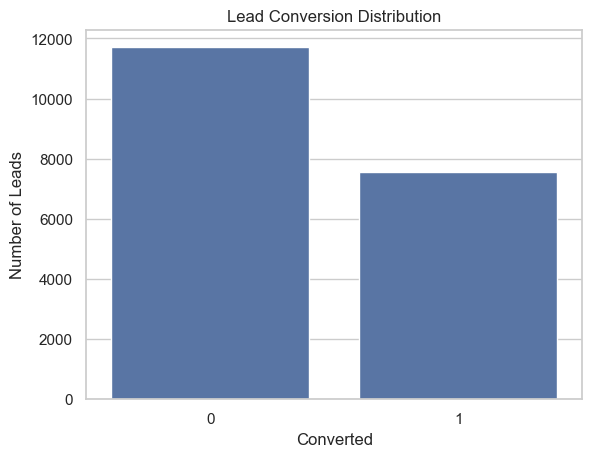

In [58]:
sns.countplot(data=df, x="Converted")

plt.title("Lead Conversion Distribution")
plt.xlabel("Converted")
plt.ylabel("Number of Leads")
plt.show()

### 12.2 Conversion Rate by Lead Source

Analyze conversion rates across different lead acquisition sources to identify differences in lead quality and conversion performance.

In [59]:
lead_source_conversion = (
    df.groupby("Lead_Source")["Converted"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(lead_source_conversion.round(2))

Lead_Source
Referral         44.70
Partner          42.63
Webinar          41.28
LinkedIn         40.11
Unknown          37.93
Website          37.53
Google Ads       37.15
Email Campaign   34.86
Name: Converted, dtype: float64

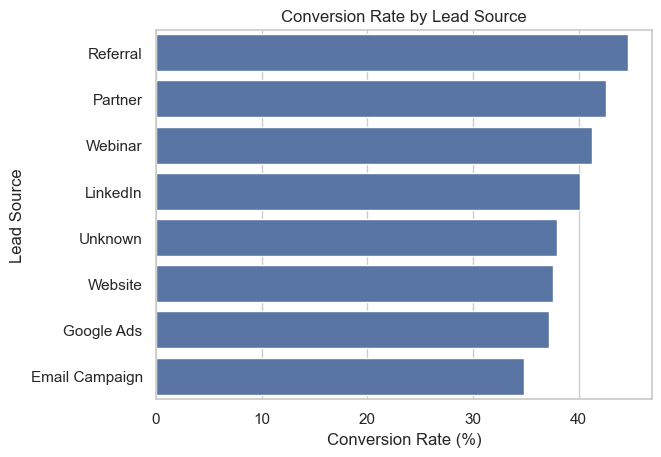

In [60]:
sns.barplot(
    x=lead_source_conversion.values,
    y=lead_source_conversion.index
)

plt.title("Conversion Rate by Lead Source")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Lead Source")
plt.show()

### 12.3 Conversion Rate by Demo Attendance

Analyze whether leads who attended a product demonstration have different conversion rates compared with leads who did not attend a demonstration.

In [61]:
demo_conversion = (
    df.groupby("Demo_Attended")["Converted"]
    .mean()
    .mul(100)
    .round(2)
)

display(demo_conversion)

Demo_Attended
No    23.22
Yes   57.42
Name: Converted, dtype: float64

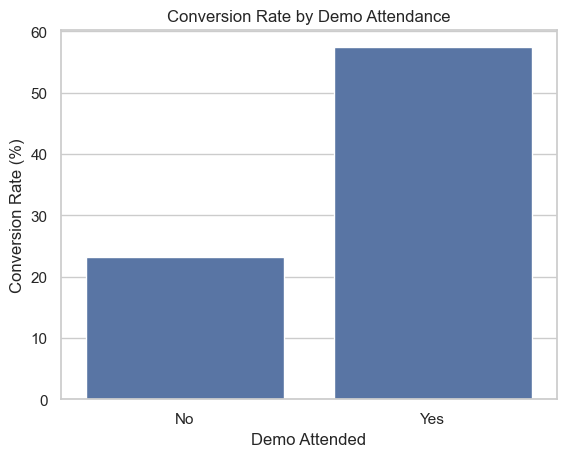

In [62]:
sns.barplot(
    x=demo_conversion.index,
    y=demo_conversion.values
)

plt.title("Conversion Rate by Demo Attendance")
plt.xlabel("Demo Attended")
plt.ylabel("Conversion Rate (%)")
plt.show()

### 12.4 Conversion Rate by Decision Maker

Analyze whether leads involving a decision maker have different conversion rates compared with leads where a decision maker is not identified.

In [63]:
decision_conversion = (
    df.groupby("Decision_Maker")["Converted"]
    .mean()
    .mul(100)
    .round(2)
)

display(decision_conversion)

Decision_Maker
No    32.95
Yes   50.12
Name: Converted, dtype: float64

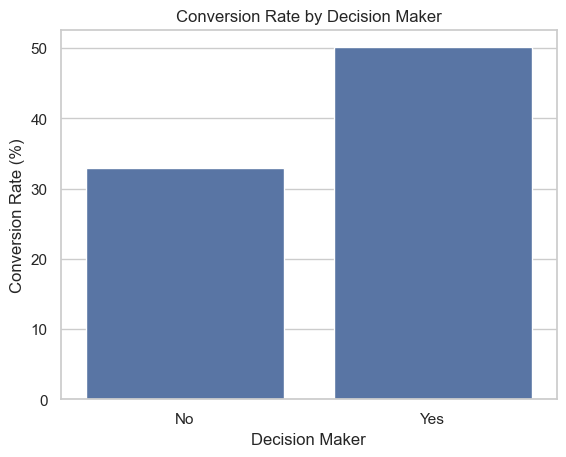

In [64]:
sns.barplot(
    x=decision_conversion.index,
    y=decision_conversion.values
)

plt.title("Conversion Rate by Decision Maker")
plt.xlabel("Decision Maker")
plt.ylabel("Conversion Rate (%)")
plt.show()

### 12.5 Website Visits and Conversion

Analyze how conversion rates vary across different levels of website engagement.

Website visits will be grouped into meaningful ranges to make the relationship easier to interpret.

In [65]:
bins = [0, 5, 10, 20, 40, 100]
labels = ["0–5", "6–10", "11–20", "21–40", "40+"]

df["Website_Visit_Band"] = pd.cut(
    df["Website_Visits"],
    bins=bins,
    labels=labels,
    include_lowest=True)

In [66]:
website_conversion = (
    df.groupby("Website_Visit_Band", observed=False)["Converted"]
    .mean()
    .mul(100)
    .round(2))

display(website_conversion)

Website_Visit_Band
0–5     16.46
6–10    20.18
11–20   29.61
21–40   52.63
40+     80.39
Name: Converted, dtype: float64

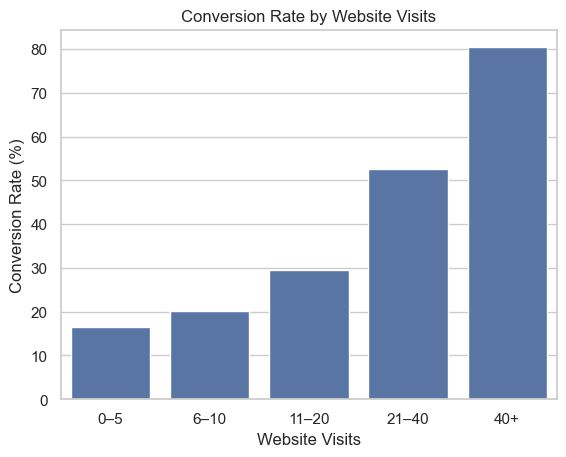

In [67]:
sns.barplot(
    x=website_conversion.index,
    y=website_conversion.values
)

plt.title("Conversion Rate by Website Visits")
plt.xlabel("Website Visits")
plt.ylabel("Conversion Rate (%)")
plt.show()

### 12.6 Recency and Conversion

Analyze how the number of days since the last lead interaction is associated with conversion.

Leads will be grouped into recency bands to make the relationship easier to interpret.

In [68]:
bins = [0, 7, 14, 30, 60, 120]
labels = ["0–7", "8–14", "15–30", "31–60", "61–120"]

df["Recency_Band"] = pd.cut(
    df["Days_Since_Last_Interaction"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [69]:
recency_conversion = (
    df.groupby("Recency_Band", observed=False)["Converted"]
    .mean()
    .mul(100)
    .round(2)
)

display(recency_conversion)

Recency_Band
0–7      80.28
8–14     65.63
15–30    45.76
31–60    26.21
61–120   21.62
Name: Converted, dtype: float64

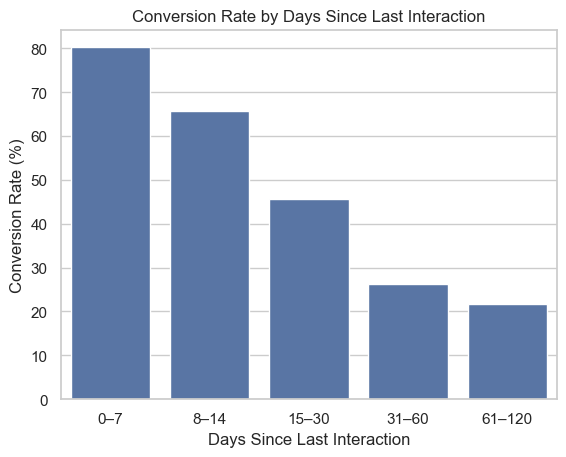

In [70]:
sns.barplot(
    x=recency_conversion.index,
    y=recency_conversion.values
)

plt.title("Conversion Rate by Days Since Last Interaction")
plt.xlabel("Days Since Last Interaction")
plt.ylabel("Conversion Rate (%)")
plt.show()

### 12.7 Estimated Budget and Conversion

Analyze how lead conversion varies across different estimated budget ranges.

Budget bands will be used to make the relationship between commercial potential and conversion easier to interpret.

In [71]:
bins = [0, 50000, 100000, 250000, 500000, 5000000]
labels = ["<50K", "50K–100K", "100K–250K", "250K–500K", "500K+"]

df["Budget_Band"] = pd.cut(
    df["Estimated_Budget"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [72]:
budget_conversion = (
    df.groupby("Budget_Band", observed=False)["Converted"]
    .mean()
    .mul(100)
    .round(2)
)

display(budget_conversion)

Budget_Band
<50K        30.38
50K–100K    39.22
100K–250K   47.47
250K–500K   53.31
500K+       64.52
Name: Converted, dtype: float64

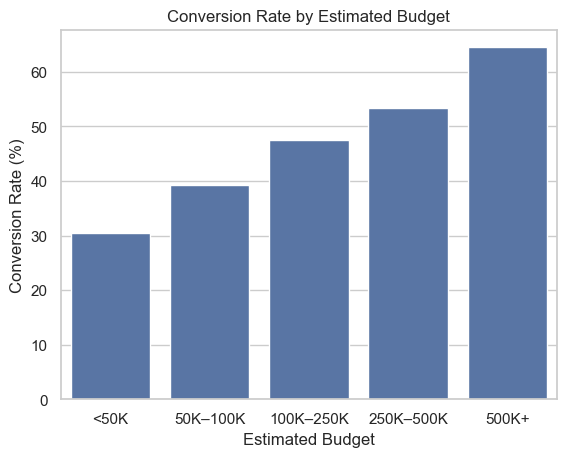

In [73]:
sns.barplot(
    x=budget_conversion.index,
    y=budget_conversion.values
)

plt.title("Conversion Rate by Estimated Budget")
plt.xlabel("Estimated Budget")
plt.ylabel("Conversion Rate (%)")
plt.show()

### 12.8 Email Engagement and Conversion

Analyze whether higher email engagement is associated with higher lead conversion.

Email clicks will be grouped into meaningful ranges to identify differences in conversion rates.

In [74]:
bins = [-1, 0, 2, 5, 10, 100]
labels = ["0", "1–2", "3–5", "6–10", "10+"]

df["Email_Click_Band"] = pd.cut(
    df["Email_Clicks"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [75]:
email_click_conversion = (
    df.groupby("Email_Click_Band", observed=False)["Converted"]
    .mean()
    .mul(100)
    .round(2)
)

display(email_click_conversion)

Email_Click_Band
0      29.00
1–2    35.74
3–5    45.77
6–10   62.92
10+    25.00
Name: Converted, dtype: float64

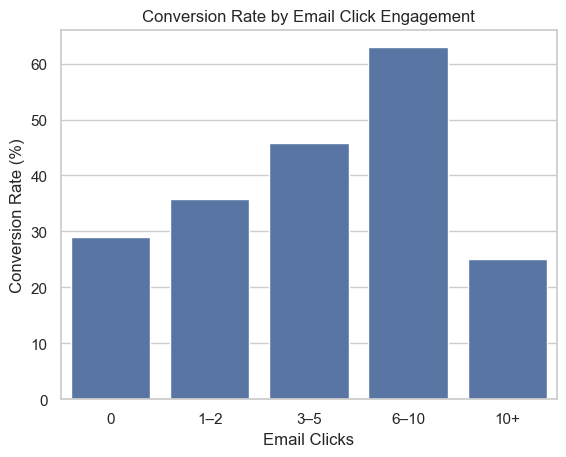

In [76]:
sns.barplot(
    x=email_click_conversion.index,
    y=email_click_conversion.values
)

plt.title("Conversion Rate by Email Click Engagement")
plt.xlabel("Email Clicks")
plt.ylabel("Conversion Rate (%)")
plt.show()

#### 12.8.1  Validate Email Click Band Sizes

Review the number of leads in each email-click band before interpreting conversion-rate differences.

This helps determine whether each observed conversion rate is based on a sufficiently large number of observations.

In [77]:
email_click_counts = (
    df["Email_Click_Band"]
    .value_counts()
    .sort_index()
)

display(email_click_counts)

Email_Click_Band
0         462
1–2     10782
3–5      6218
6–10       89
10+         4
Name: count, dtype: int64

### 12.9 Numerical Feature Correlation with Conversion

Analyze the correlation between numerical features and the binary `Converted` target.

This provides an initial view of which numerical variables are most strongly associated with lead conversion and will support later feature selection and model interpretation.

In [78]:
numeric_features = df.select_dtypes(include="number").columns

correlation_with_target = (
    df[numeric_features]
    .corr()["Converted"]
    .drop("Converted")
    .sort_values(ascending=False)
)

display(correlation_with_target.to_frame("Correlation"))

,Correlation
Website_Visits,0.42
Pages_Viewed,0.39
Content_Downloads,0.37
Product_Page_Visits,0.35
Previous_Interactions,0.30
Contact_Requests,0.28
Sales_Rep_Interactions,0.15
Email_Opens,0.12
Email_Clicks,0.11
Estimated_Budget,0.09


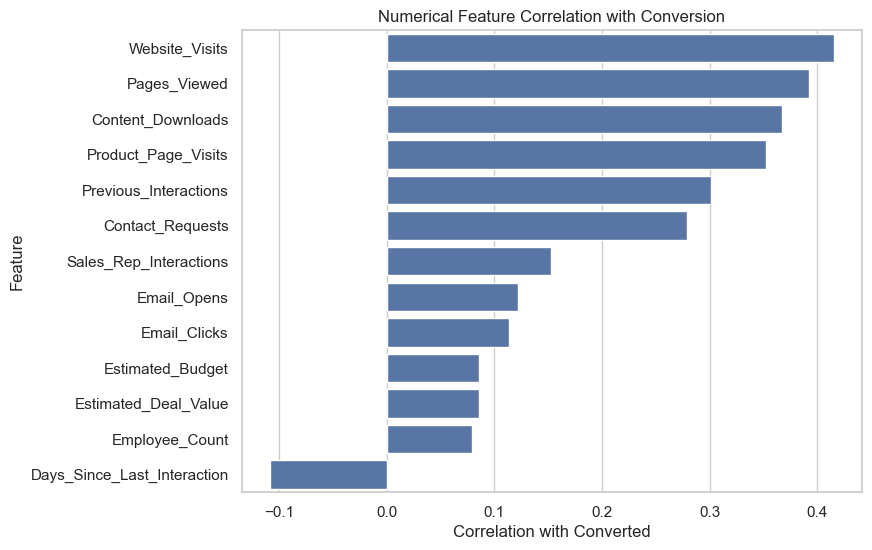

In [79]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=correlation_with_target.values,
    y=correlation_with_target.index
)

plt.title("Numerical Feature Correlation with Conversion")
plt.xlabel("Correlation with Converted")
plt.ylabel("Feature")
plt.show()

### 12.10 Feature-to-Feature Correlation Analysis

Examine correlations among numerical features to identify strongly related variables and potential redundancy before machine learning.

In [80]:
correlation_matrix = df[numeric_features].corr()

display(correlation_matrix.round(2))

,Employee_Count,Sales_Rep_Interactions,Previous_Interactions,Days_Since_Last_Interaction,Website_Visits,Pages_Viewed,Email_Opens,Email_Clicks,Content_Downloads,Estimated_Budget,Estimated_Deal_Value,Contact_Requests,Product_Page_Visits,Converted
Employee_Count,1.00,0.03,0.06,-0.01,0.09,0.08,0.19,0.11,0.08,0.83,0.77,0.06,0.08,0.08
Sales_Rep_Interactions,0.03,1.00,0.31,-0.08,0.28,0.25,0.08,0.08,0.23,0.03,0.03,0.16,0.24,0.15
Previous_Interactions,0.06,0.31,1.00,-0.15,0.51,0.48,0.15,0.15,0.42,0.06,0.06,0.29,0.43,0.30
Days_Since_Last_Interaction,-0.01,-0.08,-0.15,1.00,-0.21,-0.21,-0.05,-0.03,-0.17,-0.02,-0.01,-0.10,-0.18,-0.11
Website_Visits,0.09,0.28,0.51,-0.21,1.00,0.93,0.21,0.10,0.82,0.10,0.09,0.49,0.84,0.42
Pages_Viewed,0.08,0.25,0.48,-0.21,0.93,1.00,0.19,0.09,0.77,0.08,0.08,0.46,0.78,0.39
Email_Opens,0.19,0.08,0.15,-0.05,0.21,0.19,1.00,0.43,0.17,0.20,0.19,0.14,0.17,0.12
Email_Clicks,0.11,0.08,0.15,-0.03,0.10,0.09,0.43,1.00,0.09,0.11,0.10,0.11,0.08,0.11
Content_Downloads,0.08,0.23,0.42,-0.17,0.82,0.77,0.17,0.09,1.00,0.07,0.07,0.40,0.69,0.37
Estimated_Budget,0.83,0.03,0.06,-0.02,0.10,0.08,0.20,0.11,0.07,1.00,0.94,0.06,0.08,0.09


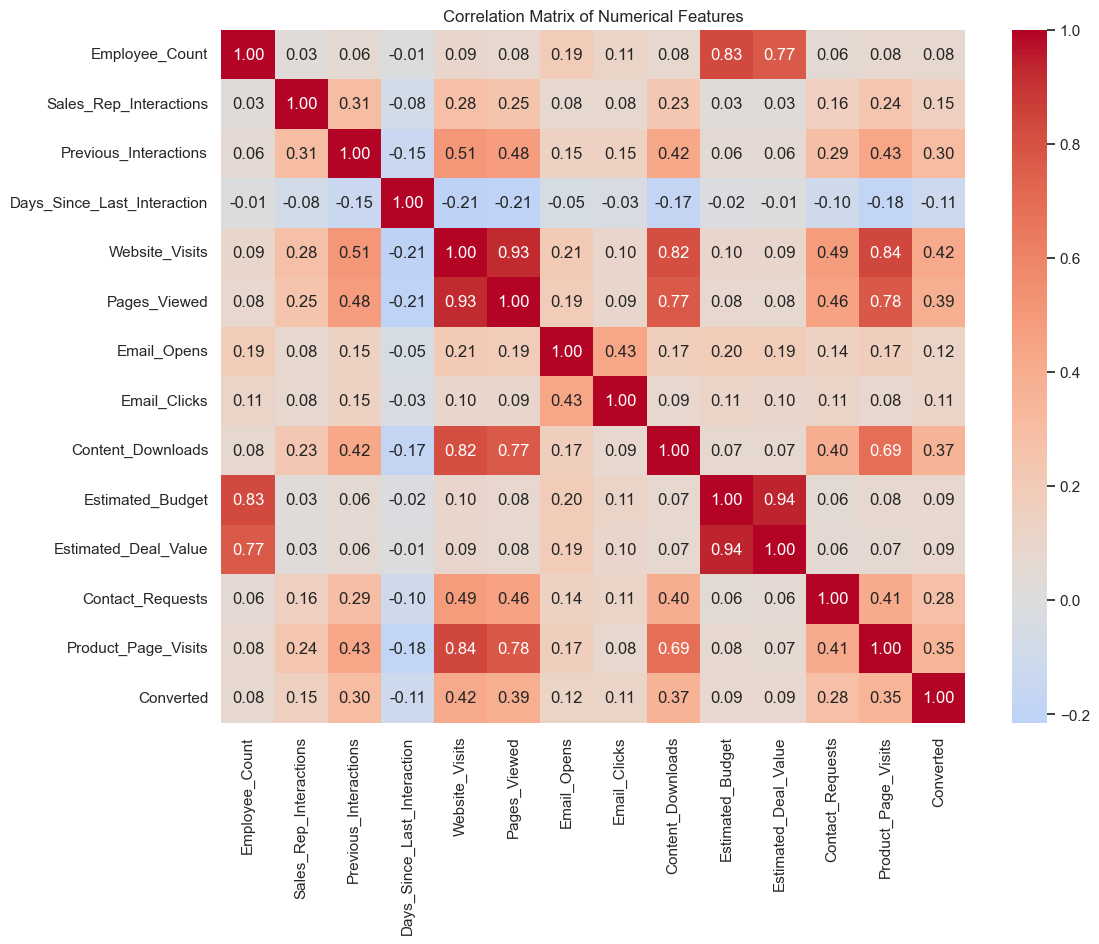

In [81]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### 12.11 Identify Highly Correlated Features

Identify numerical feature pairs with an absolute correlation greater than 0.80.

These relationships will be documented and considered during model feature selection.

In [82]:
corr_pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_corr = (
    corr_pairs.stack()
    .reset_index()
)

high_corr.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr = high_corr[
    high_corr["Correlation"].abs() > 0.80
].sort_values(
    "Correlation",
    key=lambda x: x.abs(),
    ascending=False
)

display(high_corr)

,Feature_1,Feature_2,Correlation
81,Estimated_Budget,Estimated_Deal_Value,0.94
46,Website_Visits,Pages_Viewed,0.93
53,Website_Visits,Product_Page_Visits,0.84
8,Employee_Count,Estimated_Budget,0.83
49,Website_Visits,Content_Downloads,0.82


### 12.12 Conversion Rate by Industry

Analyze the conversion rate across different industries to identify differences in lead conversion patterns.

In [83]:
industry_conversion = (
    df.groupby("Industry")["Converted"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

display(industry_conversion)

Industry
IT Services             42.07
Telecommunications      41.20
Financial Services      40.23
Healthcare              39.55
Unknown                 39.50
Manufacturing           39.35
Professional Services   39.23
Retail                  37.63
Logistics               37.22
Real Estate             37.21
Education               36.17
Name: Converted, dtype: float64

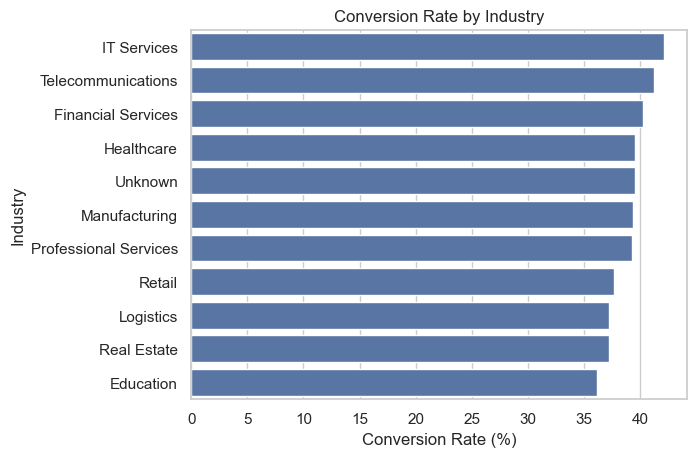

In [84]:
sns.barplot(
    x=industry_conversion.values,
    y=industry_conversion.index
)

plt.title("Conversion Rate by Industry")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Industry")
plt.show()

### 12.13 Conversion Rate by Campaign Type

Analyze conversion rates across campaign types to understand whether different marketing approaches are associated with different lead outcomes.

In [85]:
campaign_conversion = (
    df.groupby("Campaign_Type")["Converted"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

display(campaign_conversion)

Campaign_Type
Product Demo          41.03
Unknown               40.52
Webinar               40.27
Enterprise Outreach   39.74
Free Trial            38.92
Content Marketing     36.56
Name: Converted, dtype: float64

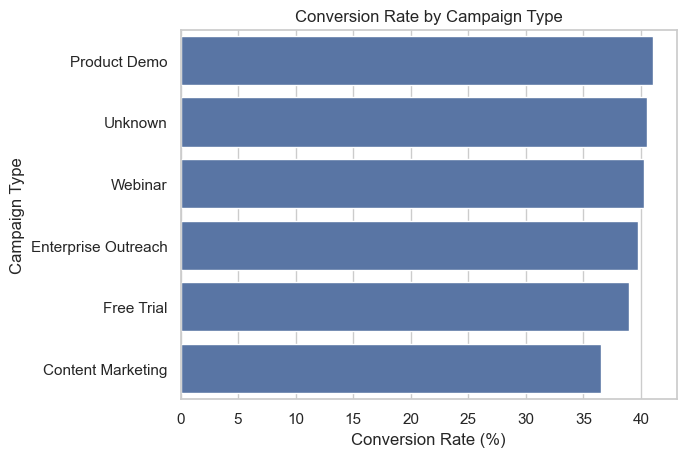

In [86]:
sns.barplot(
    x=campaign_conversion.values,
    y=campaign_conversion.index
)

plt.title("Conversion Rate by Campaign Type")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Campaign Type")
plt.show()

### 12.14 Company Size and Conversion

Analyze conversion rates across different company-size groups.

Employee count will be grouped into business-oriented size categories to make the relationship easier to interpret.

In [87]:
company_bins = [0, 50, 250, 1000, 5000]
company_labels = ["Small", "Medium", "Large", "Enterprise"]

df["Company_Size"] = pd.cut(
    df["Employee_Count"],
    bins=company_bins,
    labels=company_labels,
    include_lowest=True
)

In [88]:
company_conversion = (
    df.groupby("Company_Size", observed=False)["Converted"]
    .mean()
    .mul(100)
    .round(2)
)

display(company_conversion)

Company_Size
Small        34.88
Medium       44.49
Large        51.94
Enterprise   52.46
Name: Converted, dtype: float64

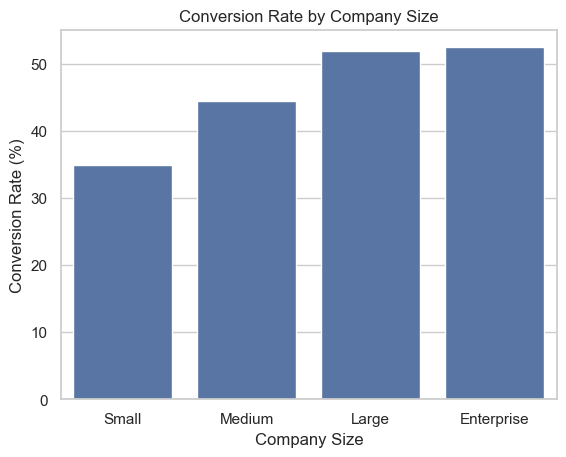

In [89]:
sns.barplot(
    x=company_conversion.index,
    y=company_conversion.values
)

plt.title("Conversion Rate by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Conversion Rate (%)")
plt.show()

## 13. Remove EDA Helper Columns

Remove temporary categorical bands created solely for exploratory analysis.

These variables were used to understand relationships during EDA and are not automatically retained as modeling features.

In [91]:
eda_helper_columns = [
    "Website_Visit_Band",
    "Recency_Band",
    "Budget_Band",
    "Email_Click_Band"
]

df.drop(columns=eda_helper_columns, inplace=True)

## 14. Feature Engineering

### 14.1 Create Total Interactions

Create a combined interaction feature representing the total number of previous and sales-representative interactions associated with each lead.

Missing values are preserved rather than treated as zero.

In [92]:
df["Total_Interactions"] = (
    df["Previous_Interactions"] +
    df["Sales_Rep_Interactions"]
)

In [93]:
df[[
    "Previous_Interactions",
    "Sales_Rep_Interactions",
    "Total_Interactions"
]].head(10)

,Previous_Interactions,Sales_Rep_Interactions,Total_Interactions
0,6.00,4.00,10.00
1,3.00,1.00,4.00
2,2.00,2.00,4.00
3,12.00,4.00,16.00
4,6.00,5.00,11.00
5,4.00,3.00,7.00
6,17.00,5.00,22.00
7,0.00,0.00,0.00
8,3.00,0.00,3.00
9,0.00,0.00,0.00


### 14.2 Create Digital Engagement Score

Create a composite digital engagement score using website activity, page views, email clicks, content downloads, and product-page visits.

The score is scaled to approximately 0–100 using predefined business limits rather than dataset-derived statistics, avoiding data leakage.

In [95]:
engagement_limits = {
    "Website_Visits": 100,
    "Pages_Viewed": 200,
    "Email_Clicks": 20,
    "Content_Downloads": 20,
    "Product_Page_Visits": 50
}

engagement_features = list(engagement_limits.keys())

normalized = pd.DataFrame(index=df.index)

for col, limit in engagement_limits.items():
    normalized[col] = (df[col] / limit).clip(upper=1)

In [96]:
df["Digital_Engagement_Score"] = (
    normalized.mean(axis=1, skipna=True) * 100
)

In [97]:
df[[
    "Website_Visits",
    "Pages_Viewed",
    "Email_Clicks",
    "Content_Downloads",
    "Product_Page_Visits",
    "Digital_Engagement_Score"
]].head(10)

,Website_Visits,Pages_Viewed,Email_Clicks,Content_Downloads,Product_Page_Visits,Digital_Engagement_Score
0,7.00,10.00,3.00,1.00,NaN,8.00
1,18.00,28.00,3.00,1.00,8.00,13.60
2,13.00,21.00,1.00,2.00,7.00,10.50
3,8.00,20.00,3.00,2.00,NaN,10.75
4,38.00,78.00,NaN,6.00,24.00,38.75
5,15.00,22.00,2.00,3.00,9.00,13.80
6,25.00,61.00,3.00,4.00,6.00,20.50
7,18.00,NaN,1.00,3.00,8.00,13.50
8,8.00,23.00,NaN,1.00,4.00,8.12
9,19.00,43.00,1.00,5.00,4.00,15.70


### 14.3 Create Budget per Employee

Create a derived feature representing estimated budget relative to company size.

This provides a normalized view of commercial potential across companies of different sizes.

In [98]:
df["Budget_per_Employee"] = (
    df["Estimated_Budget"] / df["Employee_Count"]
)

In [99]:
df[[
    "Employee_Count",
    "Estimated_Budget",
    "Budget_per_Employee"
]].head(10)

,Employee_Count,Estimated_Budget,Budget_per_Employee
0,260.00,"161,000.00",619.23
1,10.00,"51,000.00","5,100.00"
2,14.00,"54,000.00","3,857.14"
3,6.00,"47,000.00","7,833.33"
4,73.00,"73,000.00","1,000.00"
5,16.00,"53,000.00","3,312.50"
6,24.00,"55,000.00","2,291.67"
7,107.00,"97,000.00",906.54
8,10.00,"48,000.00","4,800.00"
9,4.00,"48,000.00","12,000.00"


#### 14.3.1 Validate Budget per Employee

Review the distribution of the newly created `Budget_per_Employee` feature to identify extreme values that may need treatment before modeling.

In [100]:
df["Budget_per_Employee"].describe()

count   17,376.00
mean     2,566.66
std      2,699.49
min         14.68
25%      1,000.00
50%      1,615.38
75%      2,950.00
max     16,000.00
Name: Budget_per_Employee, dtype: float64

In [101]:
df["Budget_per_Employee"].nlargest(10)

1294    16,000.00
3379    16,000.00
5666    16,000.00
7881    16,000.00
9155    16,000.00
16119   16,000.00
811     15,666.67
993     15,666.67
1062    15,666.67
1264    15,666.67
Name: Budget_per_Employee, dtype: float64

### 14.4 Create Deal-to-Budget Ratio

Create a ratio between estimated deal value and estimated budget to capture the relative commercial value of each lead.

Both variables represent pre-conversion estimates, so the derived feature does not use the conversion outcome.

In [102]:
df["Deal_to_Budget_Ratio"] = (
    df["Estimated_Deal_Value"] / df["Estimated_Budget"]
)

In [103]:
df[[
    "Estimated_Budget",
    "Estimated_Deal_Value",
    "Deal_to_Budget_Ratio"
]].head(10)

,Estimated_Budget,Estimated_Deal_Value,Deal_to_Budget_Ratio
0,"161,000.00","175,000.00",1.09
1,"51,000.00","35,000.00",0.69
2,"54,000.00","65,000.00",1.20
3,"47,000.00","55,000.00",1.17
4,"73,000.00","115,000.00",1.58
5,"53,000.00","45,000.00",0.85
6,"55,000.00","45,000.00",0.82
7,"97,000.00",NaN,NaN
8,"48,000.00","35,000.00",0.73
9,"48,000.00","50,000.00",1.04


#### 14.4.1 Validate Deal-to-Budget Ratio

Review the distribution and extreme values of `Deal_to_Budget_Ratio` to identify any unrealistic or highly skewed observations.

In [104]:
df["Deal_to_Budget_Ratio"].describe()

count   16,604.00
mean         1.10
std          0.26
min          0.61
25%          0.87
50%          1.09
75%          1.32
max          1.60
Name: Deal_to_Budget_Ratio, dtype: float64

In [105]:
df["Deal_to_Budget_Ratio"].nlargest(10)

1462    1.60
17458   1.60
4955    1.59
3019    1.58
4125    1.58
11497   1.58
15728   1.58
19204   1.58
886     1.58
3663    1.58
Name: Deal_to_Budget_Ratio, dtype: float64

In [106]:
df["Deal_to_Budget_Ratio"].nsmallest(10)

1460    0.61
2104    0.61
7956    0.61
10657   0.61
11780   0.61
15481   0.61
16423   0.61
7438    0.61
12091   0.61
17690   0.61
Name: Deal_to_Budget_Ratio, dtype: float64

### 14.5 Review Engineered Features

Review the newly created features and confirm that the dataset contains the intended business and engagement features before final validation.

In [107]:
engineered_features = [
    "Company_Size",
    "Total_Interactions",
    "Digital_Engagement_Score",
    "Budget_per_Employee",
    "Deal_to_Budget_Ratio"
]

display(df[engineered_features].head())

,Company_Size,Total_Interactions,Digital_Engagement_Score,Budget_per_Employee,Deal_to_Budget_Ratio
0,Large,10.00,8.00,619.23,1.09
1,Small,4.00,13.60,"5,100.00",0.69
2,Small,4.00,10.50,"3,857.14",1.20
3,Small,16.00,10.75,"7,833.33",1.17
4,Medium,11.00,38.75,"1,000.00",1.58


In [108]:
df.shape

(19269, 28)

## 15. Final Missing-Value Review

Review the remaining missing values after data cleaning and feature engineering.

These values will not be manually imputed in this notebook. Numerical and categorical imputation will be incorporated into the machine learning preprocessing pipelines using training data only.

In [109]:
count_per_null(df)

,Feature,Null_Count,Null%
15,Deal_to_Budget_Ratio,2665,13.83
14,Budget_per_Employee,1893,9.82
7,Email_Clicks,1714,8.90
9,Estimated_Budget,1668,8.66
6,Email_Opens,1646,8.54
13,Total_Interactions,1483,7.70
5,Pages_Viewed,1478,7.67
4,Website_Visits,1305,6.77
8,Content_Downloads,1242,6.45
11,Product_Page_Visits,1192,6.19


In [110]:
required_columns = [
    "Lead_ID",
    "Lead_Date",
    "Converted"
]

df[required_columns].isna().sum()

Lead_ID      0
Lead_Date    0
Converted    0
dtype: int64

## 16. Final Dataset Validation

Perform a final validation of the cleaned and feature-engineered dataset before exporting it for machine learning.

The validation confirms that identifiers, target values, dates, duplicates, and data types are appropriate for downstream modeling.

In [111]:
print("Dataset shape:", df.shape)

print("\nDuplicate Lead IDs:", df["Lead_ID"].duplicated().sum())

print("\nMissing Lead IDs:", df["Lead_ID"].isna().sum())

print("Missing Converted values:", df["Converted"].isna().sum())

print("\nLead Date range:")
print(df["Lead_Date"].min(), "to", df["Lead_Date"].max())

Dataset shape: (19269, 28)

Duplicate Lead IDs: 0

Missing Lead IDs: 0
Missing Converted values: 0

Lead Date range:
2024-01-01 00:00:00 to 2026-08-30 00:00:00


In [112]:
df.dtypes

Lead_ID                                object
Lead_Date                      datetime64[ns]
Industry                               object
State                                  object
Employee_Count                        float64
Lead_Source                            object
Campaign_Type                          object
Sales_Rep_Interactions                float64
Previous_Interactions                 float64
Days_Since_Last_Interaction           float64
Website_Visits                        float64
Pages_Viewed                          float64
Email_Opens                           float64
Email_Clicks                          float64
Content_Downloads                     float64
Demo_Attended                          object
Estimated_Budget                      float64
Estimated_Deal_Value                  float64
Decision_Maker                         object
Contact_Requests                      float64
Product_Page_Visits                   float64
Trial_Started                     

In [113]:
df.head()

,Lead_ID,Lead_Date,Industry,State,Employee_Count,Lead_Source,Campaign_Type,Sales_Rep_Interactions,Previous_Interactions,Days_Since_Last_Interaction,Website_Visits,Pages_Viewed,Email_Opens,Email_Clicks,Content_Downloads,Demo_Attended,Estimated_Budget,Estimated_Deal_Value,Decision_Maker,Contact_Requests,Product_Page_Visits,Trial_Started,Converted,Company_Size,Total_Interactions,Digital_Engagement_Score,Budget_per_Employee,Deal_to_Budget_Ratio
0,L000001,2024-03-27,Financial Services,Rajasthan,260.00,Website,Free Trial,4.00,6.00,26.00,7.00,10.00,13.00,3.00,1.00,No,"161,000.00","175,000.00",Yes,0.00,NaN,No,0,Large,10.00,8.00,619.23,1.09
1,L000002,2026-01-23,Logistics,West Bengal,10.00,Google Ads,Free Trial,1.00,3.00,33.00,18.00,28.00,10.00,3.00,1.00,No,"51,000.00","35,000.00",No,0.00,8.00,No,0,Small,4.00,13.60,"5,100.00",0.69
2,L000003,2025-09-28,Financial Services,West Bengal,14.00,LinkedIn,Content Marketing,2.00,2.00,32.00,13.00,21.00,9.00,1.00,2.00,Yes,"54,000.00","65,000.00",No,1.00,7.00,No,0,Small,4.00,10.50,"3,857.14",1.20
3,L000005,2025-02-25,Healthcare,Kerala,6.00,Website,Enterprise Outreach,4.00,12.00,NaN,8.00,20.00,8.00,3.00,2.00,No,"47,000.00","55,000.00",No,0.00,NaN,No,0,Small,16.00,10.75,"7,833.33",1.17
4,L000006,2026-04-15,Professional Services,Rajasthan,73.00,LinkedIn,Product Demo,5.00,6.00,20.00,38.00,78.00,8.00,NaN,6.00,Yes,"73,000.00","115,000.00",Yes,1.00,24.00,Yes,1,Medium,11.00,38.75,"1,000.00",1.58


## 17. Export Cleaned Dataset

Export the cleaned and feature-engineered dataset as a CSV file.

This dataset will serve as the common input for the classification and clustering notebooks.

In [114]:
output_path = Path("../Dataset/cleaned_leads.csv")

df.to_csv(output_path, index=False)

print(f"Cleaned dataset saved successfully to: {output_path}")
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("File exported successfully.")

Cleaned dataset saved successfully to: ..\Dataset\cleaned_leads.csv
Final shape: 19,269 rows × 28 columns
File exported successfully.
